Note：Even with identical code and software environment, differences in GPU hardware architecture and optimizations 
(e.g., Tensor Cores and memory bandwidth) can still lead to minor variations in results, 
causing small fluctuations in validation accuracy without affecting the overall conclusions. 
In our experiment, the Classifier(CuP+CAF) achieves 0.9922 validation accuracy on RTX 3090 and 0.9951 on Tesla T4.


In [ ]:
from matplotlib import font_manager
import matplotlib.pyplot as plt
# register and use Arial font in Matplotlib figures
font_manager.fontManager.addfont('ARIAL.TTF')
# Set global plotting defaults
plt.rcParams.update({
    'font.size': 20,
    'font.family': 'Arial',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})

In [2]:
# Set random seeds for reproducibility 
import glob
import numpy as np
import random
import torch
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

##### Data Loading

In [3]:
# Load CuP traces from .npy files and split them into train/val/test subsets with a fixed random seed
def load_and_split_traces(npy_path, label, seed=42):
    data = np.load(npy_path, allow_pickle=True)  
    traces = list(data)
    
    # Reproducible shuffling
    random.seed(seed)
    random.shuffle(traces)
    n_total = len(traces)
    n_train = int(n_total * 0.7)
    n_val = int(n_total * 0.15)
    n_test = n_total - n_train - n_val
    train_samples = [(t, label) for t in traces[:n_train]]
    val_samples   = [(t, label) for t in traces[n_train:n_train + n_val]]
    test_samples  = [(t, label) for t in traces[n_train + n_val:]]
    return train_samples, val_samples, test_samples

cup_paths = glob.glob("../data/CuP-CAF/CuP-0.1mM_train_val_test.npy")
cup_train_samples = []
cup_val_samples = []
cup_test_samples = []

for path in cup_paths:
    # Label=0 for CuP class; use the same seed to keep splits consistent across runs
    train_part, val_part, test_part = load_and_split_traces(path, label=0, seed=42)
    cup_train_samples.extend(train_part)
    cup_val_samples.extend(val_part)
    cup_test_samples.extend(test_part)
    
# Quick sanity check of split sizes
print(f"CuP training trace count: {len(cup_train_samples)}")
print(f"CuP validation trace count: {len(cup_val_samples)}")
print(f"CuP test trace count: {len(cup_test_samples)}")

CuP training trace count: 2325
CuP validation trace count: 498
CuP test trace count: 499


In [4]:
# Load CuP+CAF traces from .npy files, split them into train/val/test subsets, 
# and merge with the CuP (negative) samples.
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import os

caf_paths = glob.glob("../data/CuP-CAF/CuP+CAF-1_2(0.2mM)_train_val.npy")
caf_train_samples = []
caf_val_samples = []

for path in caf_paths:
    data = np.load(path, allow_pickle=True)
    traces = list(data)  
    # Reproducible shuffle before splitting
    random.seed(42)
    random.shuffle(traces)
    n_total = len(traces)
    n_train = int(n_total * 0.8)
    n_val = n_total - n_train
    caf_train_samples.extend([(t, 1) for t in traces[:n_train]])
    caf_val_samples.extend([(t, 1) for t in traces[n_train:]])

# Merge positives with CuP negatives to form final train/val sets    
train_samples = cup_train_samples + caf_train_samples
val_samples   = cup_val_samples   + caf_val_samples

# Quick sanity check of split sizes
print(f"CAF training trace count: {len(caf_train_samples)}")
print(f"CAF validation trace count: {len(caf_val_samples)}")

CAF training trace count: 2217
CAF validation trace count: 555


In [5]:
# Dataset wrapper that converts each 1D conductance trace into paired time-domain 
# and frequency-domain (FFT magnitude) inputs.
class TraceDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        trace, label = self.samples[idx]
        trace = np.array(trace, dtype=np.float32)
        # Time-domain input
        x_time = torch.tensor(trace).unsqueeze(0)  
        # Frequency-domain input
        freq = np.fft.rfft(trace)
        mag = np.abs(freq)
        x_freq = torch.tensor(mag[np.newaxis, :], dtype=torch.float32)

        return x_time, x_freq, label

##### Model

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class TFC(nn.Module):
    def __init__(self, configs):
        super(TFC, self).__init__()
        
        # Time-domain encoder
        self.encoder_time = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=9, padding=4),
            nn.InstanceNorm1d(64, affine=True),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.InstanceNorm1d(128, affine=True),
            nn.GELU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.InstanceNorm1d(128, affine=True),
            nn.GELU(),
            
            nn.Flatten(),
            nn.Linear(128 * 750, 128),

            nn.LayerNorm(128), 
            nn.GELU(),
            nn.Dropout(0.25)
        )
        
        # Frequency-domain encoder
        self.encoder_freq = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.InstanceNorm1d(64, affine=True),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.InstanceNorm1d(128, affine=True),
            nn.GELU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.InstanceNorm1d(128, affine=True),
            nn.GELU(),
            
            nn.Flatten(),
            nn.Linear(128 * 375, 128),
                
            nn.LayerNorm(128), 
            nn.GELU(),
            nn.Dropout(0.25)
        )

        # Projection heads
        self.projector_t = nn.Sequential(
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU()
        )
        
        self.projector_f = nn.Sequential(
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU()
        )

    def forward(self, x_in_t, x_in_f, mode="both"):
        # Return encoder features (h_*) and projected features (z_*)
        h_t, h_f = None, None
        z_t, z_f = None, None

        # Compute time branch if requested
        if mode in ["both", "time"]:
            h_t = self.encoder_time(x_in_t)  
            z_t = self.projector_t(h_t)       

        # Compute frequency branch if requested    
        if mode in ["both", "freq"]:
            h_f = self.encoder_freq(x_in_f)   
            z_f = self.projector_f(h_f)        

        return h_t, h_f, z_t, z_f

# classifier
class target_classifier(nn.Module):
    def __init__(self, configs):
        super(target_classifier, self).__init__()
        # classifier on concatenated (time, freq) features
        self.logits = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),       
            nn.Linear(128 * 2, 64), 
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, h_t, h_f):
         # In time-domain mode, use time-domain features
         # In frequency-domain mode, use frequency-domain features
         # In time-frequency fusion mode, use both time-domain and frequency-domain features
        if h_t is None: h_t = torch.zeros_like(h_f)
        if h_f is None: h_f = torch.zeros_like(h_t)
        
        h = torch.cat([h_t, h_f], dim=1) 
        out = self.logits(h)
        return out

##### Model Training

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report,accuracy_score
from mpl_toolkits.axes_grid1 import make_axes_locatable
from collections import Counter
import matplotlib.colors as mcolors

# Compute the consistency loss between time- and frequency-domain embeddings.
def ConsistencyLoss(z1, z2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    return F.mse_loss(z1, z2)

# Train the model for one epoch with optional time/frequency/both modality settings.
def train_one_epoch(tfc_model, classifier, dataloader, optimizer, criterion, mode="both"):
    tfc_model.train()
    classifier.train()
    total_loss = 0

    for x_t, x_f, y in dataloader:
        x_t, x_f, y = x_t.to(device), x_f.to(device), y.to(device)
        h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
        logits = classifier(h_t, h_f)
        
        # Classification loss (+ optional consistency regularization)
        ce_loss = criterion(logits, y)
        if mode == "both":
            loss_c = ConsistencyLoss(z_t, z_f)
            loss = ce_loss + 0.2 * loss_c
        else:
            loss = ce_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

# Evaluate the model
def evaluate(tfc_model, classifier, dataloader, mode="both", return_acc=False, save_path=None):
    tfc_model.eval()
    classifier.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x_t, x_f, y in dataloader:
            x_t, x_f = x_t.to(device), x_f.to(device)
            h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
            logits = classifier(h_t, h_f)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
            
    # Metrics summary
    print(f"\n[Mode={mode}] Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))
    acc = accuracy_score(all_labels, all_preds)
    print(f"[Mode={mode}] Accuracy: {acc:.4f}")

    # Plot confusion matrix only when meaningful (>=2 classes and not perfect accuracy)
    unique_labels = np.unique(all_labels)
    if (acc < 1.0) and (len(unique_labels) >= 2):
        cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

        with np.errstate(divide='ignore', invalid='ignore'):
            cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_normalized = np.nan_to_num(cm_normalized)

        display_labels = ["CuP", "CuP+CAF"]
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Custom colormap for better contrast
        colors = ["#FFFFFF", "#F3A697", "#F17D65"]
        cmap_custom = mcolors.LinearSegmentedColormap.from_list("white_to_red", colors)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                                      display_labels=display_labels)
        disp.plot(cmap=cmap_custom, values_format='.3f', ax=ax, colorbar=False)
        
        # Colorbar and axis styling
        im = disp.im_
        im.set_clim(0, 1)

        cbar = fig.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=20)
        cbar.ax.yaxis.label.set_size(22)

        plt.setp(ax.get_yticklabels(), ha="right", multialignment="center", fontsize=20)
        ax.set_xlabel("Predicted label", fontsize=22, fontweight='normal')
        ax.set_ylabel("True label", fontsize=22, fontweight='normal')
        plt.setp(ax.get_xticklabels(), ha='center', fontsize=20)
        plt.setp(ax.get_yticklabels(), rotation=90, va='center', fontsize=20)

        for text in disp.ax_.texts:
            text.set_fontsize(22)
            val = disp.confusion_matrix[int(text.get_position()[1])][int(text.get_position()[0])]
            text.set_color('white' if val > 0.5 else 'black')

        plt.tight_layout()

        # Save figure if requested
        if save_path:
            dir_name = os.path.dirname(save_path)
            if dir_name:
                os.makedirs(dir_name, exist_ok=True)
            plt.savefig(save_path, dpi=600, bbox_inches='tight')

        plt.show()

    else:
        if len(unique_labels) < 2:
            print("Only one true class is present; skipping confusion matrix plotting.")
        else:
            print("Accuracy is 100%; skipping confusion matrix plotting.")

    if return_acc:
        return acc

    
# Report the predicted class distribution over a dataloader
def predict_class_distribution(tfc_model, classifier, dataloader, device):
    tfc_model.eval()
    classifier.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_t, x_f, y in dataloader:
            x_t, x_f = x_t.to(device), x_f.to(device)
            h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
            logits = classifier(h_t, h_f)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    counter = Counter(all_preds)
    total = sum(counter.values())
    for cls_idx in sorted(counter.keys()):
        count = counter[cls_idx]
        percent = 100 * count / total
    return counter

Train set: CuP= 2325 , CAF= 2217
Using class weights: CuP=1.95, CAF=2.05

Running MODE = both
[Epoch 1] Loss: 0.2012

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9572    0.9880    0.9723       498
           1     0.9882    0.9582    0.9730       526

    accuracy                         0.9727      1024
   macro avg     0.9727    0.9731    0.9727      1024
weighted avg     0.9731    0.9727    0.9727      1024

[Mode=both] Accuracy: 0.9727


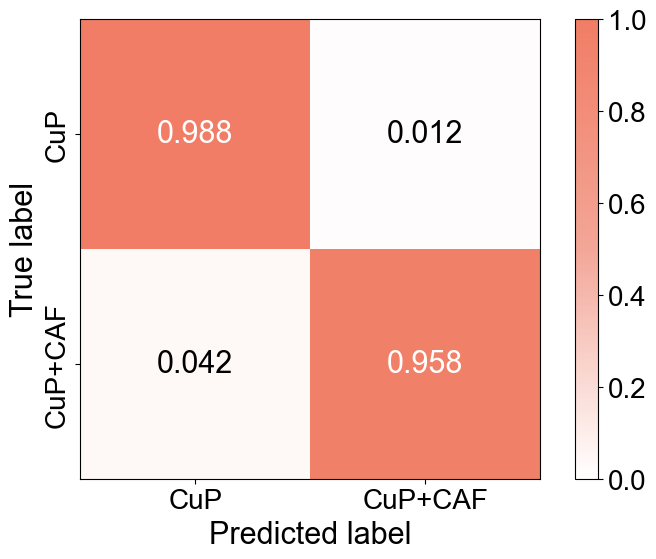

[Epoch 2] Loss: 0.0504

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9821    0.9900    0.9860       498
           1     0.9904    0.9829    0.9866       526

    accuracy                         0.9863      1024
   macro avg     0.9862    0.9864    0.9863      1024
weighted avg     0.9864    0.9863    0.9863      1024

[Mode=both] Accuracy: 0.9863


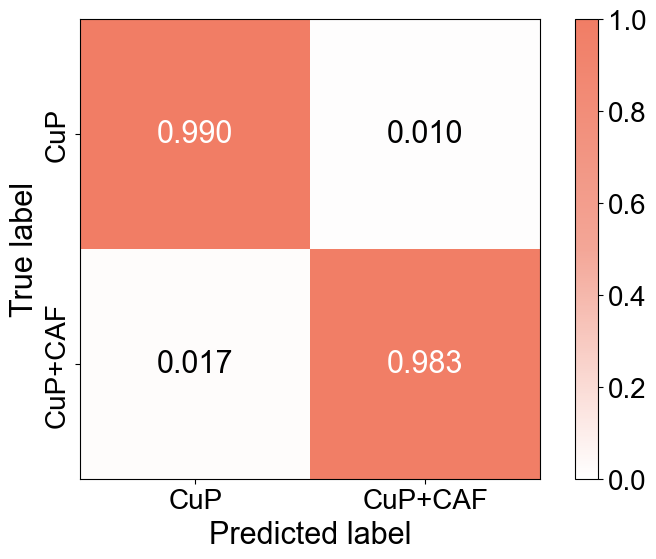

[Epoch 3] Loss: 0.0353

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9821    0.9900    0.9860       498
           1     0.9904    0.9829    0.9866       526

    accuracy                         0.9863      1024
   macro avg     0.9862    0.9864    0.9863      1024
weighted avg     0.9864    0.9863    0.9863      1024

[Mode=both] Accuracy: 0.9863


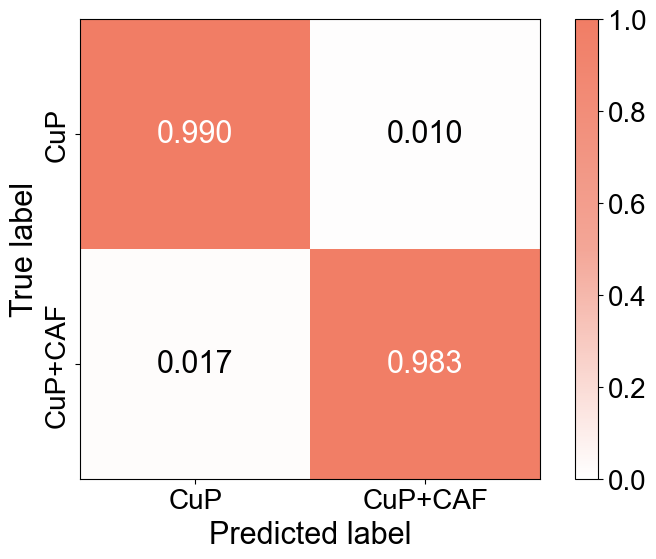

[Epoch 4] Loss: 0.0321

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9705    0.9920    0.9811       498
           1     0.9922    0.9715    0.9817       526

    accuracy                         0.9814      1024
   macro avg     0.9814    0.9817    0.9814      1024
weighted avg     0.9817    0.9814    0.9814      1024

[Mode=both] Accuracy: 0.9814


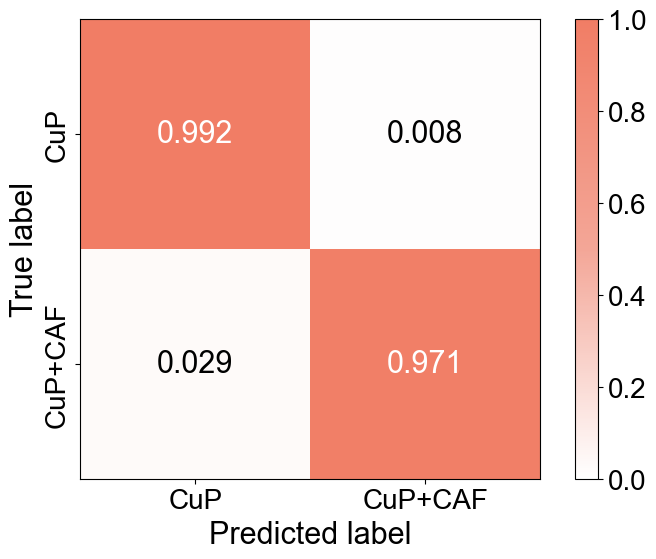

[Epoch 5] Loss: 0.0221

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9687    0.9940    0.9812       498
           1     0.9942    0.9696    0.9817       526

    accuracy                         0.9814      1024
   macro avg     0.9814    0.9818    0.9814      1024
weighted avg     0.9818    0.9814    0.9814      1024

[Mode=both] Accuracy: 0.9814


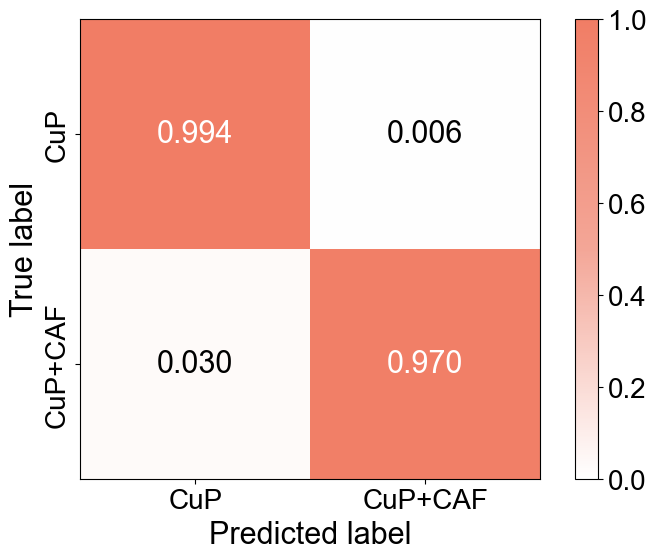

[Epoch 6] Loss: 0.0141

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9880    0.9920    0.9900       498
           1     0.9924    0.9886    0.9905       526

    accuracy                         0.9902      1024
   macro avg     0.9902    0.9903    0.9902      1024
weighted avg     0.9902    0.9902    0.9902      1024

[Mode=both] Accuracy: 0.9902


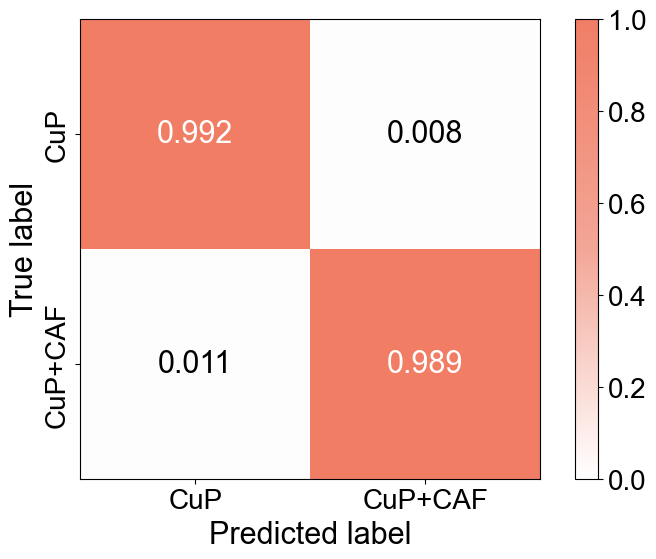

[Epoch 7] Loss: 0.0091

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9779    0.9888       498
           1     0.9795    1.0000    0.9897       526

    accuracy                         0.9893      1024
   macro avg     0.9898    0.9890    0.9892      1024
weighted avg     0.9895    0.9893    0.9893      1024

[Mode=both] Accuracy: 0.9893


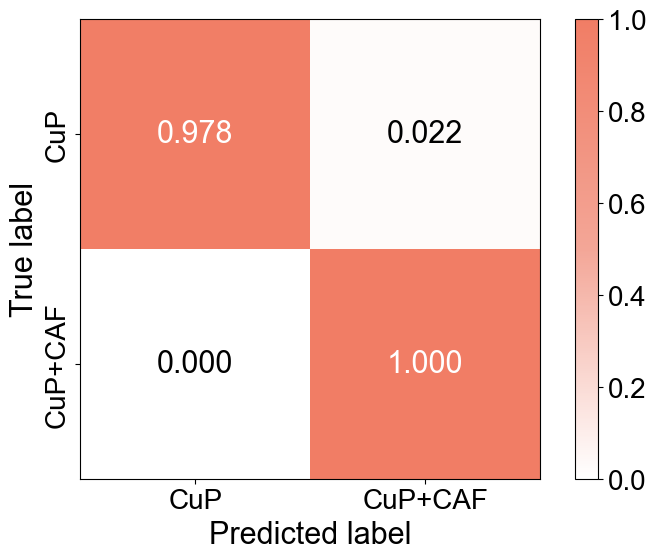

[Epoch 8] Loss: 0.0066

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9724    0.9920    0.9821       498
           1     0.9922    0.9734    0.9827       526

    accuracy                         0.9824      1024
   macro avg     0.9823    0.9827    0.9824      1024
weighted avg     0.9826    0.9824    0.9824      1024

[Mode=both] Accuracy: 0.9824


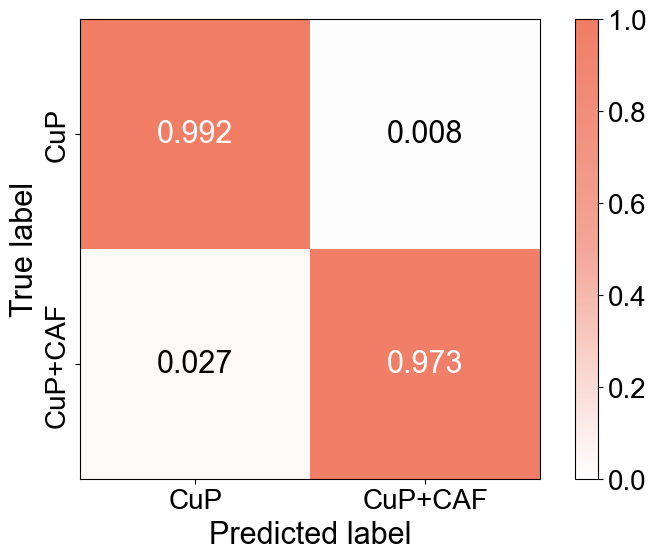

[Epoch 9] Loss: 0.0030

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9839    0.9909       498
           1     0.9850    0.9981    0.9915       526

    accuracy                         0.9912      1024
   macro avg     0.9915    0.9910    0.9912      1024
weighted avg     0.9913    0.9912    0.9912      1024

[Mode=both] Accuracy: 0.9912


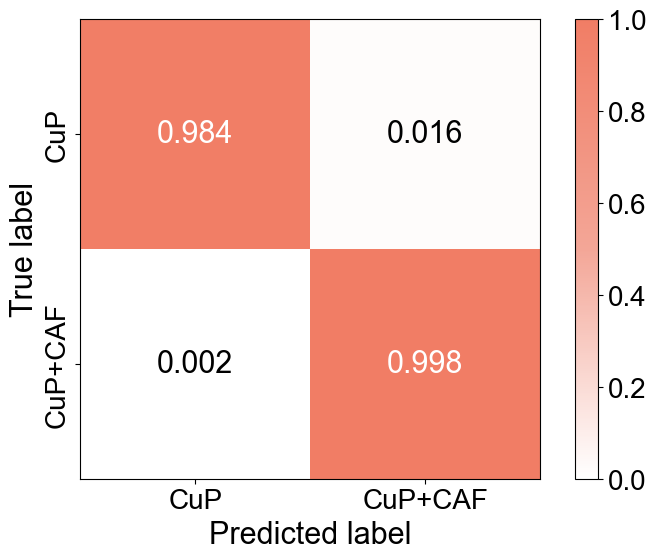

[Epoch 10] Loss: 0.0072

[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     0.9960    0.9880    0.9919       498
           1     0.9887    0.9962    0.9924       526

    accuracy                         0.9922      1024
   macro avg     0.9923    0.9921    0.9922      1024
weighted avg     0.9922    0.9922    0.9922      1024

[Mode=both] Accuracy: 0.9922


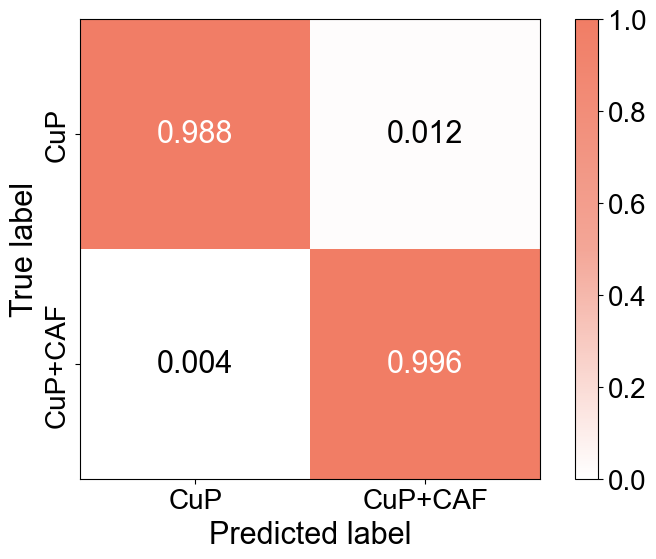

In [8]:
# Traning
set_seed(42)

# Build dataloaders for train/val
train_loader = DataLoader(TraceDataset(train_samples), batch_size=32, shuffle=True, drop_last=True)
val_loader   = DataLoader(TraceDataset(val_samples), batch_size=32, shuffle=False, drop_last=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Minimal config container
class Config:
    TSlength_aligned_t = 1500  
    TSlength_aligned_f = 751   
    num_classes_target = 2
configs = Config()

# Build an optimizer that updates only the selected modality branch(es) plus the classifier.
def build_optimizer(tfc_model, classifier, mode="both", lr=4e-4):
    params = []
    if mode in ("both", "time"):
        params += list(tfc_model.encoder_time.parameters()) + list(tfc_model.projector_t.parameters())
    if mode in ("both", "freq"):
        params += list(tfc_model.encoder_freq.parameters()) + list(tfc_model.projector_f.parameters())
    params += list(classifier.parameters())
    return torch.optim.Adam(params, lr=lr)

# Compute class weights to mitigate imbalance
num_cup = sum(label == 0 for _, label in train_samples)
num_caf = sum(label == 1 for _, label in train_samples)
total = num_cup + num_caf
print("Train set: CuP=", num_cup, ", CAF=", num_caf)

weights = torch.tensor([
    total / num_cup,
    total / num_caf
], dtype=torch.float32).to(device)
print(f"Using class weights: CuP={weights[0]:.2f}, CAF={weights[1]:.2f}")

criterion = nn.CrossEntropyLoss(weight=weights)

#   "both" = time-frequency fusion 
#   "time" = only-time-domain 
#   "freq" = only-frequency-domain
# Choose mode: "time" / "freq" / "both"
mode = "both"
set_seed(42)
print("\n" + "="*70)
print(f"Running MODE = {mode}")
print("="*70)

# Initialize model + classifier
tfc_model = TFC(configs).to(device)
classifier = target_classifier(configs).to(device)

optimizer = build_optimizer(tfc_model, classifier, mode=mode, lr=4e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=31, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(weight=weights)

# Main training loop (train + evaluate each epoch)
for epoch in range(1, 11):
    loss = train_one_epoch(tfc_model, classifier, train_loader, optimizer, criterion, mode=mode)
    scheduler.step()
    print(f"[Epoch {epoch}] Loss: {loss:.4f}")

    save_path = f"../results/CuP_CAF_confmat_{mode}_epoch{epoch:02d}.png"
    evaluate(tfc_model, classifier, val_loader, mode=mode, save_path=save_path)

In [9]:
# # Save final checkpoint (model weights + minimal metadata)
# model_save_path = f"checkpoint_{mode}_(CuP+CAF).pth"
    
# print(f"Saving model for mode {mode} to {model_save_path} ...")
    
# torch.save({
#     'tfc_model_state_dict': tfc_model.state_dict(),
#     'classifier_state_dict': classifier.state_dict(),
#     'epoch': epoch,
#     'mode': mode
# }, model_save_path)
    
# print("Save complete.")

In [10]:
# Load traces from multiple .npy files and attach a class label to each trace.
# Return a list of (trace, label) pairs.
def load_trace_level_samples(file_label_pairs):
    samples = []
    for path, label in file_label_pairs:
        data = np.load(path, allow_pickle=True) 
        for trace in data:
            trace = np.array(trace, dtype=np.float32)
            samples.append((trace, label))
    return samples

# Choose mode: "both"
mode = "both"

##### CuP-test

In [11]:
# Build CuP test set (force label=0)
# Run evaluation + prediction distribution check
final_test_samples = [(trace, 0) for trace, _ in cup_test_samples]
final_test_loader = DataLoader(TraceDataset(final_test_samples), batch_size=32, shuffle=False)

evaluate(tfc_model, classifier, final_test_loader, mode=mode)
predict_class_distribution(tfc_model, classifier, final_test_loader, device)


[Mode=both] Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9880    0.9940       499
           1     0.0000    0.0000    0.0000         0

    accuracy                         0.9880       499
   macro avg     0.5000    0.4940    0.4970       499
weighted avg     1.0000    0.9880    0.9940       499

[Mode=both] Accuracy: 0.9880
Only one true class is present; skipping confusion matrix plotting.


/root/miniconda3/envs/wzyEnv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/envs/wzyEnv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/envs/wzyEnv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Counter({0: 493, 1: 6})

##### Prediction

In [12]:
# Compute predicted CAF proportion for each concentration (used for a calibration curve)
manual_paths = [
    ("../data/CuP-CAF/CuP+CAF-1_1(0.1mM)_prediction.npy", 1E-4),
    ("../data/CuP-CAF/CuP+CAF-1_0.5(0.05mM)_prediction.npy", 5E-5),
    ("../data/CuP-CAF/CuP+CAF-10_1(0.01mM)_prediction.npy", 1E-5),
    ("../data/CuP-CAF/CuP+CAF-100_1(0.001mM)_prediction.npy", 1E-6),
    ("../data/CuP-CAF/CuP+CAF-1000_1(0.0001mM)_prediction.npy", 1E-7),
    ("../data/CuP-CAF/CuP+CAF-10000_1(0.00001mM)_prediction.npy", 1E-8),
    ("../data/CuP-CAF/CuP+CAF-100000_1(0.000001mM)_prediction.npy", 1E-9),
    ("../data/CuP-CAF/CuP+CAF-1000000_1(0.0000001mM)_prediction.npy", 1E-10),
    ("../data/CuP-CAF/CuP+CAF-10000000_1(0.00000001mM)_prediction.npy", 1E-11),
    ("../data/CuP-CAF/CuP+CAF-10^10_1(10^-14mM)_prediction.npy", 1E-14),
    ("../data/CuP-CAF/CuP+CAF-10^12_1(10^-16mM)_prediction.npy", 1E-16),
    ("../data/CuP-CAF/CuP+CAF-10^14_1(10^-18mM)_prediction.npy", 1E-18),
]

# Store (concentration, predicted CAF ratio) for downstream plotting/fitting
concentration_list = []
caf_proportion_list = []
for path, conc in manual_paths:
    try:
        # Load traces
        samples = load_trace_level_samples([(path, 1)])
        if len(samples) == 0:
            continue
        loader = DataLoader(TraceDataset(samples), batch_size=32, shuffle=False, drop_last=True)
        tfc_model.eval()
        classifier.eval()
        
        # Collect predicted class ids over all traces in this concentration file
        preds = []
        with torch.no_grad():
            for x_t, x_f, _ in loader:
                x_t, x_f = x_t.to(device), x_f.to(device)
                h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
                out = classifier(h_t, h_f)
                
                pred = torch.argmax(out, dim=1).cpu().numpy()
                preds.extend(pred.tolist())
        count = Counter(preds)
        total = len(preds)
        ratio = count.get(1, 0) / total
        print(f"[MODE={mode}] {conc:.1e} mM: CAF Ratio = {ratio:.2f}")

        concentration_list.append(conc)
        caf_proportion_list.append(ratio)
    except Exception as e:
        # Skip corrupted/missing files without breaking the whole sweep
        print(f"error")

[MODE=both] 1.0e-04 mM: CAF Ratio = 0.89
[MODE=both] 5.0e-05 mM: CAF Ratio = 0.94
[MODE=both] 1.0e-05 mM: CAF Ratio = 0.88
[MODE=both] 1.0e-06 mM: CAF Ratio = 0.99
[MODE=both] 1.0e-07 mM: CAF Ratio = 1.00
[MODE=both] 1.0e-08 mM: CAF Ratio = 0.63
[MODE=both] 1.0e-09 mM: CAF Ratio = 0.37
[MODE=both] 1.0e-10 mM: CAF Ratio = 0.56
[MODE=both] 1.0e-11 mM: CAF Ratio = 0.29
[MODE=both] 1.0e-14 mM: CAF Ratio = 0.29
[MODE=both] 1.0e-16 mM: CAF Ratio = 0.18
[MODE=both] 1.0e-18 mM: CAF Ratio = 0.11


##### Limit of Detection

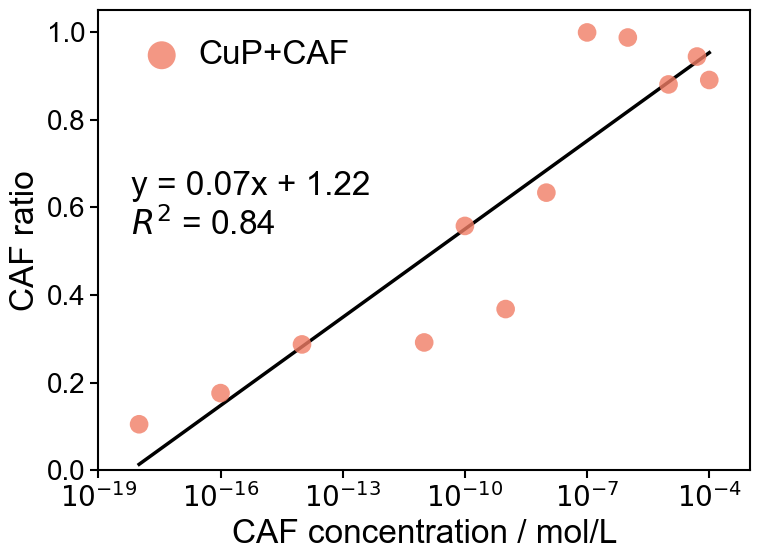

In [13]:
# Plot the calibration curve by regressing the predicted CAF ratio against log10(concentration) 
# and visualizing the fit on a log-scaled x-axis.
import matplotlib.ticker as ticker
from scipy.stats import linregress
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

# Keep only valid (positive) concentrations
valid_indices = [i for i, c in enumerate(concentration_list) if c > 0]
concentration_array = np.array(concentration_list)[valid_indices]
proportion_array = np.array(caf_proportion_list)[valid_indices]

# Linear regression in log-space: y = slope * log10(c) + intercept
log_conc = np.log10(concentration_array)
slope, intercept, r_value, _, _ = linregress(log_conc, proportion_array)

# Build fitted line in log-space, then convert x back to linear for plotting
log_x_min = np.log10(min(concentration_array))
log_x_max = np.log10(max(concentration_array))
fit_x = np.linspace(log_x_min, log_x_max, 100)
fit_y = slope * fit_x + intercept
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter: measured points (concentration vs predicted CAF ratio)
ax.scatter(concentration_array, proportion_array, 
           marker='o', s=180, c='#F17D65', alpha=0.8, edgecolors='none',zorder=10, label='CuP+CAF')

# Fit curve: plot using linear concentration values (10**fit_x) with fitted y
ax.plot(10**fit_x, fit_y, '-', color='black', lw=2.5)

# Axes setup 
ax.set_xscale("log")
ax.set_ylim(0, 1.05)
ax.set_xlim(min(concentration_array) * 0.1, max(concentration_array) * 10)
ax.set_xlabel("CAF concentration / mol/L", fontsize=24, fontweight='normal')
ax.set_ylabel("CAF ratio", fontsize=24, fontweight='normal')

# Format log x-axis ticks as 10^k
def sci_notation_formatter(x, pos):
    if x == 0:
        return "0"
    exponent = int(np.log10(x))
    return r"$10^{{{}}}$".format(exponent)
ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation_formatter))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(1.5)
ax.tick_params(width=1.5, length=6)

# Annotate regression equation and R^2 on the plot
sign = '+' if intercept >= 0 else '-'
equation_text = (
    f"y = {slope:.2f}x {sign} {abs(intercept):.2f}\n"
    f"$R^2$ = {r_value**2:.2f}"
)
ax.text(0.05, 0.65, equation_text,
        transform=ax.transAxes,
        fontsize=24,
        verticalalignment='top')

ax.legend(loc='upper left', fontsize=24, frameon=False, handletextpad=0.1, markerscale=1.5)

# Save figure for reporting
plt.tight_layout()
save_path = f"../results/CuP_CAF_{mode}_LOD.png"
plt.savefig(save_path, format='png', dpi=330, bbox_inches='tight')
plt.show()

##### Response Time

[MODE=both] 1.0e-04 mM: CAF Ratio = 0.871
[MODE=both] 5.0e-05 mM: CAF Ratio = 0.968
[MODE=both] 1.0e-05 mM: CAF Ratio = 0.935
[MODE=both] 1.0e-06 mM: CAF Ratio = 1.000
[MODE=both] 1.0e-07 mM: CAF Ratio = 1.000
[MODE=both] 1.0e-08 mM: CAF Ratio = 0.581
[MODE=both] 1.0e-09 mM: CAF Ratio = 0.452
[MODE=both] 1.0e-10 mM: CAF Ratio = 0.774
[MODE=both] 1.0e-11 mM: CAF Ratio = 0.258
[MODE=both] 1.0e-14 mM: CAF Ratio = 0.323
[MODE=both] 1.0e-16 mM: CAF Ratio = 0.065
[MODE=both] 1.0e-18 mM: CAF Ratio = 0.194


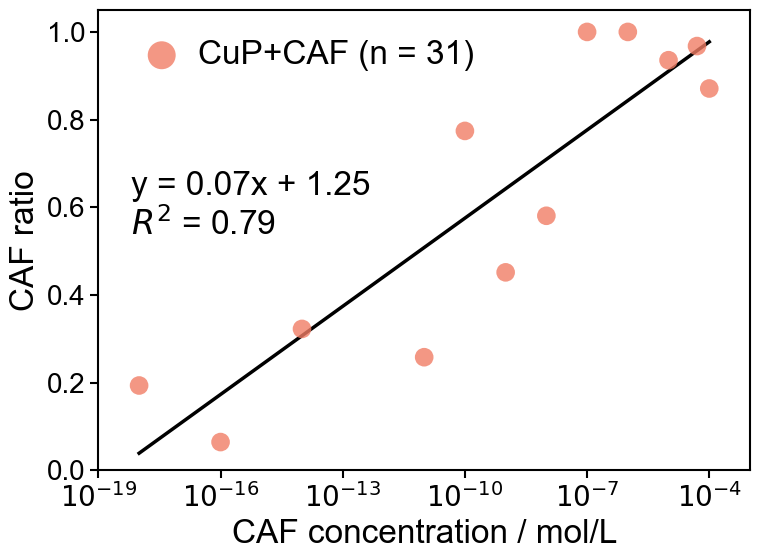

[MODE=both] 1.0e-04 mM: CAF Ratio = 0.840
[MODE=both] 5.0e-05 mM: CAF Ratio = 0.940
[MODE=both] 1.0e-05 mM: CAF Ratio = 0.940
[MODE=both] 1.0e-06 mM: CAF Ratio = 0.980
[MODE=both] 1.0e-07 mM: CAF Ratio = 1.000
[MODE=both] 1.0e-08 mM: CAF Ratio = 0.600
[MODE=both] 1.0e-09 mM: CAF Ratio = 0.540
[MODE=both] 1.0e-10 mM: CAF Ratio = 0.580
[MODE=both] 1.0e-11 mM: CAF Ratio = 0.240
[MODE=both] 1.0e-14 mM: CAF Ratio = 0.260
[MODE=both] 1.0e-16 mM: CAF Ratio = 0.360
[MODE=both] 1.0e-18 mM: CAF Ratio = 0.100


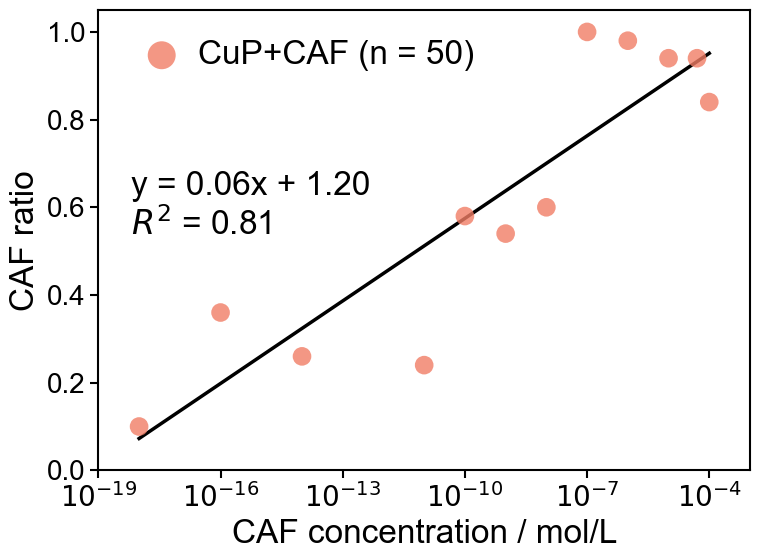

[MODE=both] 1.0e-04 mM: CAF Ratio = 0.890
[MODE=both] 5.0e-05 mM: CAF Ratio = 0.940
[MODE=both] 1.0e-05 mM: CAF Ratio = 0.920
[MODE=both] 1.0e-06 mM: CAF Ratio = 0.980
[MODE=both] 1.0e-07 mM: CAF Ratio = 1.000
[MODE=both] 1.0e-08 mM: CAF Ratio = 0.700
[MODE=both] 1.0e-09 mM: CAF Ratio = 0.370
[MODE=both] 1.0e-10 mM: CAF Ratio = 0.600
[MODE=both] 1.0e-11 mM: CAF Ratio = 0.270
[MODE=both] 1.0e-14 mM: CAF Ratio = 0.210
[MODE=both] 1.0e-16 mM: CAF Ratio = 0.200
[MODE=both] 1.0e-18 mM: CAF Ratio = 0.110


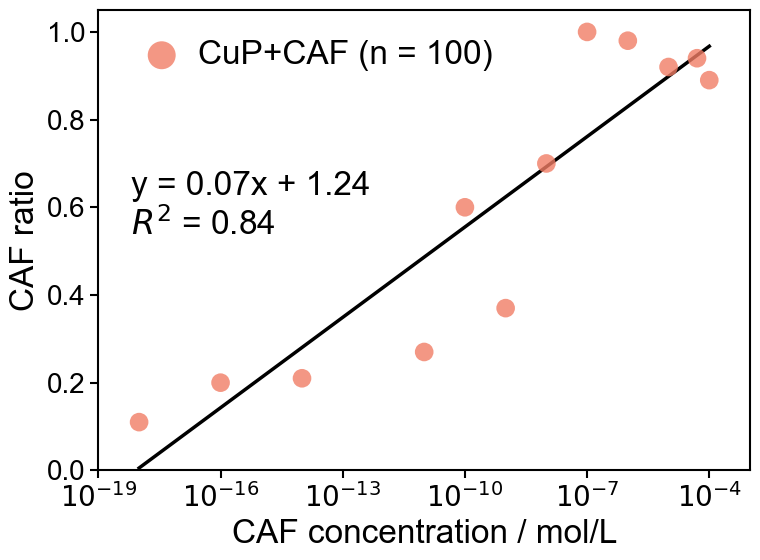

[MODE=both] 1.0e-04 mM: CAF Ratio = 0.890
[MODE=both] 5.0e-05 mM: CAF Ratio = 0.943
[MODE=both] 1.0e-05 mM: CAF Ratio = 0.881
[MODE=both] 1.0e-06 mM: CAF Ratio = 0.987
[MODE=both] 1.0e-07 mM: CAF Ratio = 0.999
[MODE=both] 1.0e-08 mM: CAF Ratio = 0.633
[MODE=both] 1.0e-09 mM: CAF Ratio = 0.368
[MODE=both] 1.0e-10 mM: CAF Ratio = 0.557
[MODE=both] 1.0e-11 mM: CAF Ratio = 0.293
[MODE=both] 1.0e-14 mM: CAF Ratio = 0.287
[MODE=both] 1.0e-16 mM: CAF Ratio = 0.176
[MODE=both] 1.0e-18 mM: CAF Ratio = 0.105


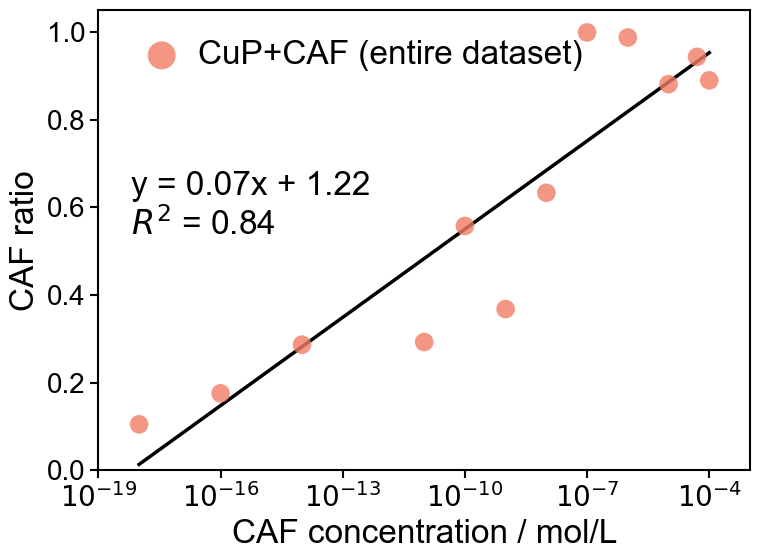

In [14]:
# Sensitivity analysis: rebuild the concentration–response curve with different per-dataset sample sizes.
# This checks how stable the predicted CAF ratio is under limited sampling.
manual_paths = [
    ("../data/CuP-CAF/CuP+CAF-1_1(0.1mM)_prediction.npy", 1E-4),
    ("../data/CuP-CAF/CuP+CAF-1_0.5(0.05mM)_prediction.npy", 5E-5),
    ("../data/CuP-CAF/CuP+CAF-10_1(0.01mM)_prediction.npy", 1E-5),
    ("../data/CuP-CAF/CuP+CAF-100_1(0.001mM)_prediction.npy", 1E-6),
    ("../data/CuP-CAF/CuP+CAF-1000_1(0.0001mM)_prediction.npy", 1E-7),
    ("../data/CuP-CAF/CuP+CAF-10000_1(0.00001mM)_prediction.npy", 1E-8),
    ("../data/CuP-CAF/CuP+CAF-100000_1(0.000001mM)_prediction.npy", 1E-9),
    ("../data/CuP-CAF/CuP+CAF-1000000_1(0.0000001mM)_prediction.npy", 1E-10),
    ("../data/CuP-CAF/CuP+CAF-10000000_1(0.00000001mM)_prediction.npy", 1E-11),
    ("../data/CuP-CAF/CuP+CAF-10^10_1(10^-14mM)_prediction.npy", 1E-14),
    ("../data/CuP-CAF/CuP+CAF-10^12_1(10^-16mM)_prediction.npy", 1E-16),
    ("../data/CuP-CAF/CuP+CAF-10^14_1(10^-18mM)_prediction.npy", 1E-18),
]

# Per-dataset subsampling settings (use "all" for full dataset)
sample_sizes_to_test = [31, 50, 100, "all"]

set_seed(42)

for n_samples in sample_sizes_to_test:
    concentration_list = []
    caf_proportion_list = []
    
    for path, conc in manual_paths:
        all_samples = load_trace_level_samples([(path, 1)])

        if n_samples == "all":
            samples_to_use = all_samples
        else:
            num_to_take = min(n_samples, len(all_samples))
            samples_to_use = random.sample(all_samples, num_to_take)

        if not samples_to_use:
            continue

        loader = DataLoader(
            TraceDataset(samples_to_use),
            batch_size=32,
            shuffle=False,
            drop_last=False
        )
        
        # Predict class ids and compute CAF proportion (pred==1)
        tfc_model.eval()
        classifier.eval()
        preds = []

        with torch.no_grad():
            for x_t, x_f, _ in loader:
                x_t, x_f = x_t.to(device), x_f.to(device)
                h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
                out = classifier(h_t, h_f)
                pred = torch.argmax(out, dim=1).cpu().numpy()
                preds.extend(pred.tolist())

        count = Counter(preds)
        total = len(preds)
        ratio = count.get(1, 0) / total
        print(f"[MODE={mode}] {conc:.1e} mM: CAF Ratio = {ratio:.3f}")

        concentration_list.append(conc)
        caf_proportion_list.append(ratio)
    # Fit in log-space: y ~ log10(concentration)
    valid_indices = [i for i, c in enumerate(concentration_list) if c > 0]
    concentration_array = np.array(concentration_list)[valid_indices]
    proportion_array = np.array(caf_proportion_list)[valid_indices]

    log_conc = np.log10(concentration_array)
    slope, intercept, r_value, _, _ = linregress(log_conc, proportion_array)
    
    # Build fitted line for visualization
    log_x_min = np.log10(min(concentration_array))
    log_x_max = np.log10(max(concentration_array))
    fit_x = np.linspace(log_x_min, log_x_max, 100)
    fit_y = slope * fit_x + intercept

    fig, ax = plt.subplots(figsize=(8, 6))

    label = f"CuP+CAF (n = {n_samples})" if n_samples != "all" else "CuP+CAF (entire dataset)"

    ax.scatter(
        concentration_array, proportion_array,
        marker="o", s=180, c="#F17D65", alpha=0.8,
        edgecolors="none", zorder=10, label=label
    )
    ax.plot(10**fit_x, fit_y, "-", color="black", lw=2.5)

    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(min(concentration_array) * 0.1, max(concentration_array) * 10)
    ax.set_xlabel("CAF concentration / mol/L", fontsize=24)
    ax.set_ylabel("CAF ratio", fontsize=24)

    # Log tick labels as 10^k
    def sci_notation_formatter(x, pos):
        if x == 0:
            return "0"
        exponent = int(np.log10(x))
        return r"$10^{{{}}}$".format(exponent)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
    ax.xaxis.set_major_formatter(FuncFormatter(sci_notation_formatter))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6)

    # Annotate regression summary (equation + R^2)
    sign = "+" if intercept >= 0 else "-"
    equation_text = (
        f"y = {slope:.2f}x {sign} {abs(intercept):.2f}\n"
        f"$R^2$ = {r_value**2:.2f}"
    )
    ax.text(
        0.05, 0.65, equation_text,
        transform=ax.transAxes,
        fontsize=24,
        verticalalignment="top"
    )

    ax.legend(loc="upper left", fontsize=24, frameon=False, handletextpad=0.1, markerscale=1.5)
    plt.tight_layout()
    
    # Save each sensitivity curve plot
    save_path = f"../results/concentration_CuP_CAF_{n_samples}_samples.png"
    plt.savefig(save_path, format="png", dpi=330, bbox_inches="tight")
    plt.show()
    plt.close(fig)


In [15]:
# Track how slope/intercept/R² change as traces-per-concentration increases.
manual_paths = [
    ("../data/CuP-CAF/CuP+CAF-1_1(0.1mM)_prediction.npy", 1E-4),
    ("../data/CuP-CAF/CuP+CAF-1_0.5(0.05mM)_prediction.npy", 5E-5),
    ("../data/CuP-CAF/CuP+CAF-10_1(0.01mM)_prediction.npy", 1E-5),
    ("../data/CuP-CAF/CuP+CAF-100_1(0.001mM)_prediction.npy", 1E-6),
    ("../data/CuP-CAF/CuP+CAF-1000_1(0.0001mM)_prediction.npy", 1E-7),
    ("../data/CuP-CAF/CuP+CAF-10000_1(0.00001mM)_prediction.npy", 1E-8),
    ("../data/CuP-CAF/CuP+CAF-100000_1(0.000001mM)_prediction.npy", 1E-9),
    ("../data/CuP-CAF/CuP+CAF-1000000_1(0.0000001mM)_prediction.npy", 1E-10),
    ("../data/CuP-CAF/CuP+CAF-10000000_1(0.00000001mM)_prediction.npy", 1E-11),
    ("../data/CuP-CAF/CuP+CAF-10^10_1(10^-14mM)_prediction.npy", 1E-14),
    ("../data/CuP-CAF/CuP+CAF-10^12_1(10^-16mM)_prediction.npy", 1E-16),
    ("../data/CuP-CAF/CuP+CAF-10^14_1(10^-18mM)_prediction.npy", 1E-18),
]

set_seed(42)

# Sampling schedule config (convert "time budget" into sample count points)
MAX_N              = 1600                                     
TRACE_LENGTH       = 1500               
DECISION_TIME_S    = 5.0                
START_N_MIN        = 10          
MEAN_JFP           = 0.575
TRACE_INTERVAL_S   = 0.30
all_data_by_conc = {}
min_samples_across_all_files = float('inf')

# Load all traces per concentration and find the smallest dataset size
for path, conc in manual_paths:
    samples = load_trace_level_samples([(path, 1)])
    all_data_by_conc[conc] = samples
    min_samples_across_all_files = min(min_samples_across_all_files, len(samples))

MAX_N = min(MAX_N, min_samples_across_all_files)  
time_per_trace = TRACE_INTERVAL_S / MEAN_JFP

# Build a set of sample counts to test (denser early, sparser later)
def build_sample_points(max_n,
                        start_n=START_N_MIN,
                        time_per_trace=time_per_trace,
                        decision_time_s=DECISION_TIME_S,
                        num_points=38,      
                        power=2.4,          
                        min_step=4):        
    t_min = start_n * time_per_trace
    t_max = max_n  * time_per_trace
    u = np.linspace(0.0, 1.0, num_points)
    t = t_min + (t_max - t_min) * (u ** power)
    n = np.rint(t / time_per_trace).astype(int)
    decision_n = int(round(decision_time_s / time_per_trace))
    n = np.concatenate(([start_n], n, [max_n, decision_n]))
    n = np.unique(n)
    n = n[(n >= start_n) & (n <= max_n)]
    n_sorted = [int(n[0])]
    for k in n[1:]:
        if k - n_sorted[-1] >= min_step:
            n_sorted.append(int(k))
    return n_sorted

sample_points = build_sample_points(MAX_N)
time_points   = [n * time_per_trace for n in sample_points]

# Predict CAF proportion for a single concentration using n randomly sampled traces
def _predict_ratio_for_conc(n, all_samples):
    k = min(n, len(all_samples))
    samples_to_use = random.sample(all_samples, k)
    loader = DataLoader(TraceDataset(samples_to_use), batch_size=32, shuffle=False, drop_last=False)
    if len(loader) == 0:
        return None
    preds = []
    with torch.no_grad():
        for x_t, x_f, _ in loader:
            x_t, x_f = x_t.to(device), x_f.to(device)
            h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
            out = classifier(h_t, h_f)
            pred = torch.argmax(out, dim=1).cpu().numpy()
            preds.extend(pred.tolist())
    if not preds:
        return None
    return Counter(preds).get(1, 0) / len(preds)

# Fit calibration at a given n: y ~ slope * log10(c) + intercept
# return (slope, intercept, R^2)
def get_fit_params_at_n_samples(n, data_source):
    concentration_list, caf_proportion_list = [], []
    for conc, all_samples in data_source.items():
        ratio = _predict_ratio_for_conc(n, all_samples)
        if ratio is None:
            continue
        concentration_list.append(conc)
        caf_proportion_list.append(ratio)
    if len(concentration_list) < 2:
        return None, None, None
    logc = np.log10(concentration_list)
    slope, intercept, r_value, *_ = linregress(logc, caf_proportion_list)
    r2 = r_value**2
    return slope, intercept, r2
tfc_model.eval()
classifier.eval()

# Track fitted parameters across sample_points
slopes, intercepts, r2s = [], [], []
for n in sample_points:
    s, b, r2 = get_fit_params_at_n_samples(n, all_data_by_conc)
    slopes.append(np.nan if s  is None else s)
    intercepts.append(np.nan if b  is None else b)
    r2s.append(np.nan if r2 is None else r2)
    print(f"  - n={n}: slope={s:.6f}, intercept={b:.6f}, R^2={r2:.4f}")

final_slope, final_intercept, final_r2 = get_fit_params_at_n_samples(min_samples_across_all_files, all_data_by_conc)
print(f"  - slope_all={final_slope:.6f}, intercept_all={final_intercept:.6f}, R^2_all={final_r2:.4f}")

# Normalize to the "all-data" fit to visualize stabilization (avoid division-by-zero)
eps = 1e-12
fs = final_slope     if abs(final_slope)     > eps else eps
fi = final_intercept if abs(final_intercept) > eps else eps
fr = final_r2        if abs(final_r2)        > eps else eps  

norm_slopes     = np.array(slopes, dtype=float)     / fs
norm_intercepts = np.array(intercepts, dtype=float) / fi
r2_array        = np.array(r2s, dtype=float)
norm_r2         = r2_array / fr                    

  - n=10: slope=0.068547, intercept=1.149827, R^2=0.6552
  - n=14: slope=0.074488, intercept=1.292328, R^2=0.8192
  - n=18: slope=0.069088, intercept=1.266921, R^2=0.9024
  - n=23: slope=0.067202, intercept=1.223110, R^2=0.8729
  - n=30: slope=0.070729, intercept=1.242466, R^2=0.8657
  - n=39: slope=0.066025, intercept=1.211903, R^2=0.7921
  - n=50: slope=0.063826, intercept=1.185644, R^2=0.8252
  - n=63: slope=0.067857, intercept=1.214399, R^2=0.8142
  - n=79: slope=0.067286, intercept=1.230954, R^2=0.8293
  - n=97: slope=0.066162, intercept=1.222262, R^2=0.8423
  - n=117: slope=0.064220, intercept=1.202142, R^2=0.8246
  - n=139: slope=0.065341, intercept=1.217007, R^2=0.8365
  - n=164: slope=0.066356, intercept=1.214994, R^2=0.8350
  - n=192: slope=0.067077, intercept=1.220183, R^2=0.8087
  - n=223: slope=0.068758, intercept=1.235394, R^2=0.8443
  - n=256: slope=0.066416, intercept=1.213347, R^2=0.8250
  - n=292: slope=0.067327, intercept=1.221396, R^2=0.8130
  - n=331: slope=0.06791

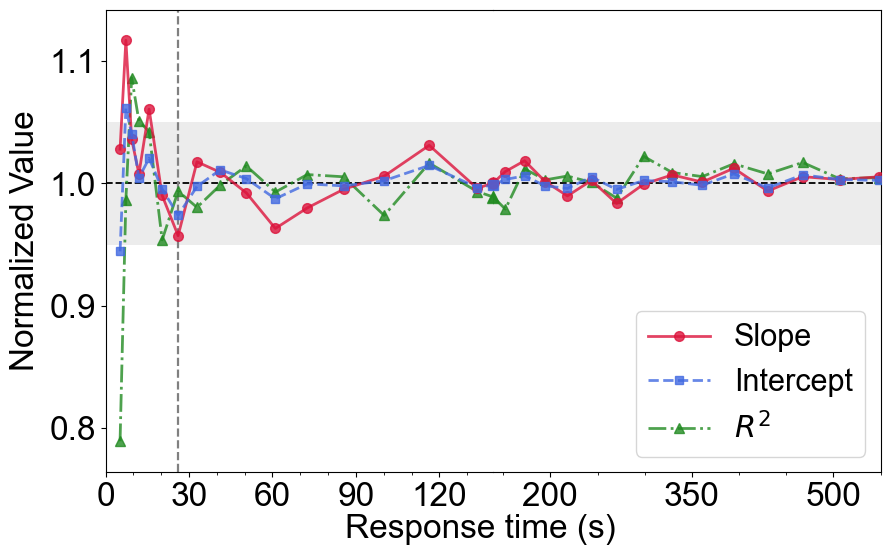

In [16]:
# Plot normalized slope/intercept/R² vs response time.

from matplotlib.ticker import MultipleLocator, FixedLocator
import matplotlib.gridspec as gridspec
from math import floor

# Global font settings for this figure
plt.rcParams.update({
    'font.size': 24,  'font.weight': 'normal',
    'xtick.labelsize': 24, 'ytick.labelsize': 24
})

# Helper: split a curve at a breakpoint (linear interpolation at the split point)
def _interp_at_break(tp, yA, yB, break_point):
    idxR = int(np.searchsorted(tp, break_point))
    idxL = max(idxR - 1, 0)
    valid_indices_A = np.where(~np.isnan(yA))[0]
    valid_indices_B = np.where(~np.isnan(yB))[0]
    
    if idxR == 0 or idxR >= len(tp) or np.isclose(tp[idxL], tp[min(idxR, len(tp)-1)]):
        yB_A = yA[idxL] if idxL in valid_indices_A else np.nan
        yB_B = yB[idxL] if idxL in valid_indices_B else np.nan
        tB = break_point
    else:
        t0, t1 = tp[idxL], tp[idxR]
        w = (break_point - t0) / (t1 - t0)
        yB_A = yA[idxL] + w * (yA[idxR] - yA[idxL]) if idxL in valid_indices_A and idxR in valid_indices_A else np.nan
        yB_B = yB[idxL] + w * (yB[idxR] - yB[idxL]) if idxL in valid_indices_B and idxR in valid_indices_B else np.nan
        tB = break_point

    tL, A_L, B_L = np.r_[tp[:idxR], tB], np.r_[yA[:idxR], yB_A], np.r_[yB[:idxR], yB_B]
    tR, A_R, B_R = np.r_[tB, tp[idxR:]], np.r_[yB_A, yA[idxR:]], np.r_[yB_B, yB[idxR:]]
    return tB, (tL, A_L, B_L), (tR, A_R, B_R)

# Use a broken x-axis layout (two panels) to show early and late time ranges
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
ax_left  = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[1], sharey=ax_left) 

ax_left.spines['right'].set_visible(False)
ax_right.spines['left'].set_visible(False)

tp = np.asarray(time_points, dtype=float)
ys = np.asarray(norm_slopes, dtype=float)
yi = np.asarray(norm_intercepts, dtype=float)

# Y-range includes a gray ROPE-style band around 1.0 (±BAND)
BAND = 0.05
y_min = min(np.nanmin(ys), np.nanmin(yi), np.nanmin(norm_r2), 1 - BAND) - 0.025
y_max = max(np.nanmax(ys), np.nanmax(yi), np.nanmax(norm_r2), 1 + BAND) + 0.025
ax_left.set_ylim(y_min, y_max)
ax_left.set_ylabel("Normalized Value", fontsize=24, labelpad=6)

for ax in (ax_left, ax_right):
    ax.axhspan(1 - BAND, 1 + BAND, facecolor='gray', alpha=0.15, zorder=-20)
    ax.axhline(1.0, color='black', linestyle='--', lw=1.3, zorder=-5)
    ax.set_facecolor('none')

# Breakpoint used for the x-axis split (left: early time, right: later time)
BREAK_POINT = 139.3
tB,  (tL,  yL,  iL), (tR,  yR,  iR)  = _interp_at_break(tp, ys,      yi,       BREAK_POINT)
tB2, (tL2, r2L, _ ), (tR2, r2R, _ ) = _interp_at_break(tp, norm_r2,  norm_r2,  BREAK_POINT)

# Plot styles
SLOPE_COLOR     = 'crimson'     
INTERCEPT_COLOR = 'royalblue'  
R2_COLOR = 'forestgreen'
ALPHA_VAL = 0.8

# Left panel (early time)
line_s_left, = ax_left.plot(tL,  yL, 'o-',  lw=2.0, ms=7, color=SLOPE_COLOR,
                            label='Slope',     zorder=5, alpha=ALPHA_VAL)
line_i_left, = ax_left.plot(tL,  iL, 's--', lw=2.0, ms=6, color=INTERCEPT_COLOR,
                            label='Intercept', zorder=5, alpha=ALPHA_VAL)
line_r2_left,= ax_left.plot(tL2, r2L, '^-.', lw=2.0, ms=7, color=R2_COLOR,
                            label=r'$R^2$',    zorder=4, alpha=ALPHA_VAL)

# Right panel (late time)
ax_right.plot(tR,  yR,  'o-',  lw=2.0, ms=7, color=SLOPE_COLOR,     zorder=5, alpha=ALPHA_VAL)
ax_right.plot(tR,  iR,  's--', lw=2.0, ms=6, color=INTERCEPT_COLOR, zorder=5, alpha=ALPHA_VAL)
ax_right.plot(tR2, r2R, '^-.', lw=2.0, ms=7, color=R2_COLOR,        zorder=4, alpha=ALPHA_VAL)

# Mark the breakpoint so the curve looks continuous across panels
ax_left.plot(tB,  yL[-1],  'o', ms=8, color=SLOPE_COLOR,     zorder=6, alpha=ALPHA_VAL)
ax_left.plot(tB,  iL[-1],  's', ms=7, color=INTERCEPT_COLOR, zorder=6, alpha=ALPHA_VAL)
ax_left.plot(tB2, r2L[-1], '^', ms=8, color=R2_COLOR,        zorder=6, alpha=ALPHA_VAL)
ax_right.plot(tB,  yR[0],  'o', ms=8, color=SLOPE_COLOR,     zorder=6, alpha=ALPHA_VAL)
ax_right.plot(tB,  iR[0],  's', ms=7, color=INTERCEPT_COLOR, zorder=6, alpha=ALPHA_VAL)
ax_right.plot(tB2, r2R[0], '^', ms=8, color=R2_COLOR,        zorder=6, alpha=ALPHA_VAL)

# Axis limits and ticks (split x-range)
ax_right.tick_params(labelleft=False, left=False)
ax_left.set_xlim(0, BREAK_POINT)
ax_left.xaxis.set_major_locator(FixedLocator([0, 30, 60, 90, 120]))
ax_left.xaxis.set_minor_locator(MultipleLocator(10))

x_max = float(np.max(time_points)) * 1.02  
ax_right.set_xlim(BREAK_POINT, 550)

ticks_right = [200, 350, 500]
ax_right.xaxis.set_major_locator(FixedLocator(ticks_right))
ax_right.xaxis.set_minor_locator(MultipleLocator(50))


fig.subplots_adjust(wspace=0)
ax_left.axvline(26, color='gray', linestyle='--', lw=1.6, zorder=-4)

fig.supxlabel("Response time (s)", fontsize=24, y=-0.012)
ax_right.legend([line_s_left, line_i_left, line_r2_left],
                ['Slope', 'Intercept', r'$R^2$'],
                loc='lower right', fontsize=22, frameon=True)

# Save and display
save_path = f"../results/CuP_CAF_response_time.png"
plt.savefig(save_path, dpi=330, bbox_inches='tight')
plt.show()
plt.close(fig)